In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from imblearn.combine import SMOTEENN
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay, f1_score, PrecisionRecallDisplay,
    precision_score, recall_score
)

In [12]:
import os
os.makedirs('../Results/XGB_Results', exist_ok=True)

In [13]:
X_train_full = pd.read_csv('../Data/X_train.csv')
X_test_full  = pd.read_csv('../Data/X_test.csv')
y_train      = pd.read_csv('../Data/y_train.csv').squeeze()
y_test       = pd.read_csv('../Data/y_test.csv').squeeze()

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f'Train: {X_train_full.shape}  |  Test: {X_test_full.shape}')
print(f'Positive rate: {y_train.mean():.3f}')
print(f'scale_pos_weight: {scale_pos_weight:.1f}')

Train: (55989, 131)  |  Test: (13998, 131)
Positive rate: 0.090
scale_pos_weight: 10.1


In [14]:
# Use XGBoost's own feature importances to select top features
selector_xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
)
selector = SelectFromModel(selector_xgb, threshold="mean")
selector.fit(X_train_full, y_train)

top_features = X_train_full.columns[selector.get_support()].tolist()
X_train_top = X_train_full[top_features]
X_test_top  = X_test_full[top_features]

print(f"Using {len(top_features)} / {X_train_full.shape[1]} features")

Using 66 / 131 features


XGBoost's built-in feature importances reduced the feature space from 131 to 66, dropping any feature whose importance fell below the mean. This removes noise and speeds up training. The baseline intentionally skips this step and uses all 131 features as a reference point.

## 2. Baseline Model

In [15]:
# Plain XGBClassifier, all features, default threshold 0.5
baseline = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
)
baseline.fit(X_train_full, y_train)

base_pred_prob = baseline.predict_proba(X_test_full)[:, 1]
base_pred      = baseline.predict(X_test_full)

print('Baseline Classification Report (threshold=0.5):')
print(classification_report(y_test, base_pred, target_names=['Not Readmitted', 'Readmitted <30']))
print(f'ROC-AUC: {roc_auc_score(y_test, base_pred_prob):.4f}')

Baseline Classification Report (threshold=0.5):
                precision    recall  f1-score   support

Not Readmitted       0.93      0.76      0.83     12741
Readmitted <30       0.14      0.41      0.21      1257

      accuracy                           0.73     13998
     macro avg       0.54      0.59      0.52     13998
  weighted avg       0.86      0.73      0.78     13998

ROC-AUC: 0.6186


The baseline struggles with the minority class — precision of 0.14 means 86% of readmission predictions are false alarms, though it catches 41% of actual cases (recall). The ROC-AUC of 0.6186 is only modestly above random (0.5), showing that default settings without any tuning are insufficient for this imbalanced problem.

## Tuned Model

In [16]:
param_dist = {
    'n_estimators':     [200, 300, 500],
    'max_depth':        [3, 4, 5, 6],
    'learning_rate':    [0.01, 0.05, 0.1, 0.15],
    'subsample':        [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5],
    'gamma':            [0, 0.1, 0.3],
}

xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
)

search = RandomizedSearchCV(
    xgb,
    param_dist,
    n_iter=40,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
search.fit(X_train_top, y_train)

print(f'\nBest CV ROC-AUC: {search.best_score_:.4f}')
print('Best params:', search.best_params_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best CV ROC-AUC: 0.6552
Best params: {'subsample': 0.9, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0.3, 'colsample_bytree': 0.8}


The search tested 40 random hyperparameter combinations across 5-fold CV (200 fits total). The best CV ROC-AUC of 0.6552 used a shallow tree (max_depth=4), learning rate (0.05), and strong regularization (gamma=0.3, min_child_weight=5) — these settings prevent the model from overfitting to the dominant majority class.

## Evaluation

In [17]:
model = search.best_estimator_
y_pred_prob = model.predict_proba(X_test_top)[:, 1]
y_pred      = model.predict(X_test_top)

print('Tuned Model at threshold=0.5:')
print(classification_report(y_test, y_pred, target_names=['Not Readmitted', 'Readmitted <30']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_pred_prob):.4f}')

Tuned Model at threshold=0.5:
                precision    recall  f1-score   support

Not Readmitted       0.94      0.69      0.80     12741
Readmitted <30       0.15      0.53      0.23      1257

      accuracy                           0.68     13998
     macro avg       0.54      0.61      0.51     13998
  weighted avg       0.87      0.68      0.75     13998

ROC-AUC: 0.6601


At the default 0.5 threshold the tuned model catches 53% of readmissions (recall) but precision is only 0.15 — most flagged patients weren't actually readmitted. The ROC-AUC of 0.6601 improves on the baseline, but 0.5 is not the optimal cutoff for imbalanced data. The next cell sweeps all thresholds to find a better one.

In [18]:
# Sweep thresholds to maximize minority class F1
thresholds = np.arange(0.05, 0.95, 0.01)
f1_scores  = [f1_score(y_test, (y_pred_prob >= t).astype(int), pos_label=1, zero_division=0)
              for t in thresholds]

best_thresh = thresholds[np.argmax(f1_scores)]
y_pred_best = (y_pred_prob >= best_thresh).astype(int)

print(f'Tuned Model at optimal threshold = {best_thresh:.2f}:')
print(classification_report(y_test, y_pred_best, target_names=['Not Readmitted', 'Readmitted <30']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_pred_prob):.4f}')

Tuned Model at optimal threshold = 0.58:
                precision    recall  f1-score   support

Not Readmitted       0.93      0.86      0.89     12741
Readmitted <30       0.20      0.35      0.25      1257

      accuracy                           0.82     13998
     macro avg       0.56      0.60      0.57     13998
  weighted avg       0.86      0.82      0.84     13998

ROC-AUC: 0.6601


Raising the threshold to **0.58** improves precision (0.20) at the cost of some recall (0.35), giving the best minority F1 of 0.25 among all three XGBoost models. The Macro F1 of 0.57 confirms this is the best overall balance. Compared to the 0.5 threshold above, fewer patients are flagged as high-risk but those who are flagged are more likely to actually be readmitted.

## SMOTE Model

In [19]:
# Balance the training set: SMOTEENN oversamples the minority class and removes noisy boundary points
smoteenn = SMOTEENN(random_state=42)
X_train_sme, y_train_sme = smoteenn.fit_resample(X_train_top, y_train)

print('Before:', pd.Series(y_train).value_counts().to_dict())
print('After: ', pd.Series(y_train_sme).value_counts().to_dict())

# No scale_pos_weight needed — SMOTEENN already handled the class imbalance at the data level
smote_model = XGBClassifier(
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
)
smote_model.fit(X_train_sme, y_train_sme)

# Get predicted probabilities, sweep thresholds to find the one that maximizes minority class F1
smote_pred_prob = smote_model.predict_proba(X_test_top)[:, 1]
smote_f1_scores   = [f1_score(y_test, (smote_pred_prob >= t).astype(int), pos_label=1, zero_division=0)
                     for t in thresholds]
smote_best_thresh = thresholds[np.argmax(smote_f1_scores)]
smote_pred_best   = (smote_pred_prob >= smote_best_thresh).astype(int)

# Evaluate on the original imbalanced test set — this reflects real-world performance
print(f'\nSMOTEENN XGBoost at threshold = {smote_best_thresh:.2f}:')
print(classification_report(y_test, smote_pred_best, target_names=['Not Readmitted', 'Readmitted <30']))
print(f'ROC-AUC: {roc_auc_score(y_test, smote_pred_prob):.4f}')

Before: {0: 50961, 1: 5028}
After:  {1: 50800, 0: 27086}

SMOTEENN XGBoost at threshold = 0.30:
                precision    recall  f1-score   support

Not Readmitted       0.93      0.79      0.85     12741
Readmitted <30       0.16      0.42      0.24      1257

      accuracy                           0.76     13998
     macro avg       0.55      0.61      0.55     13998
  weighted avg       0.86      0.76      0.80     13998

ROC-AUC: 0.6472


SMOTEENN dramatically shifted the class distribution — from ~51K non-readmitted / ~5K readmitted to ~27K / ~51K (minority now outnumbers majority after ENN cleaning removes noisy samples). Despite this aggressive rebalancing the ROC-AUC (0.6472) is lower than the tuned model, though recall improves to 0.42. The low threshold (0.30) reflects that the model predicts readmission more liberally after being trained on balanced data.

## Model Comparison

In [20]:
results = {
    'Model':                ['Baseline', 'Tuned', 'SMOTE'],
    'Features':             [X_train_full.shape[1], len(top_features), len(top_features)],
    'Imbalance handling':   ['scale_pos_weight', 'scale_pos_weight + tuned', 'SMOTEENN oversampling'],
    'Threshold':            [0.50, round(best_thresh, 2), round(smote_best_thresh, 2)],
    'Precision (minority)': [
        round(precision_score(y_test, base_pred,       pos_label=1, zero_division=0), 3),
        round(precision_score(y_test, y_pred_best,     pos_label=1, zero_division=0), 3),
        round(precision_score(y_test, smote_pred_best, pos_label=1, zero_division=0), 3),
    ],
    'Recall (minority)': [
        round(recall_score(y_test, base_pred),       3),
        round(recall_score(y_test, y_pred_best),     3),
        round(recall_score(y_test, smote_pred_best), 3),
    ],
    'F1 (minority)': [
        round(f1_score(y_test, base_pred,       pos_label=1, zero_division=0), 3),
        round(f1_score(y_test, y_pred_best,     pos_label=1, zero_division=0), 3),
        round(f1_score(y_test, smote_pred_best, pos_label=1, zero_division=0), 3),
    ],
    'Macro F1': [
        round(f1_score(y_test, base_pred,       average='macro', zero_division=0), 3),
        round(f1_score(y_test, y_pred_best,     average='macro', zero_division=0), 3),
        round(f1_score(y_test, smote_pred_best, average='macro', zero_division=0), 3),
    ],
    'ROC-AUC': [
        round(roc_auc_score(y_test, base_pred_prob),  4),
        round(roc_auc_score(y_test, y_pred_prob),     4),
        round(roc_auc_score(y_test, smote_pred_prob), 4),
    ],
}

pd.DataFrame(results)

,Model,Features,Imbalance handling,Threshold,Precision (minority),Recall (minority),F1 (minority),Macro F1,ROC-AUC
0,Baseline,131,scale_pos_weight,0.50,0.144,0.414,0.213,0.524,0.6186
1,Tuned,66,scale_pos_weight + tuned,0.58,0.198,0.347,0.252,0.573,0.6601
2,SMOTE,66,SMOTEENN oversampling,0.30,0.164,0.422,0.236,0.545,0.6472


**Tuned** wins on precision, ROC-AUC, minority F1, and Macro F1 — making it the best XGBoost variant overall. **SMOTE** and **Baseline** have better recall but sacrifice too much precision. The SMOTE threshold of 0.30 vs Tuned's 0.58 highlights a key effect of resampling: after SMOTEENN training the model is much more aggressive about predicting readmission, requiring a lower probability cutoff to find the optimal balance.

## 6. Confusion Matrices

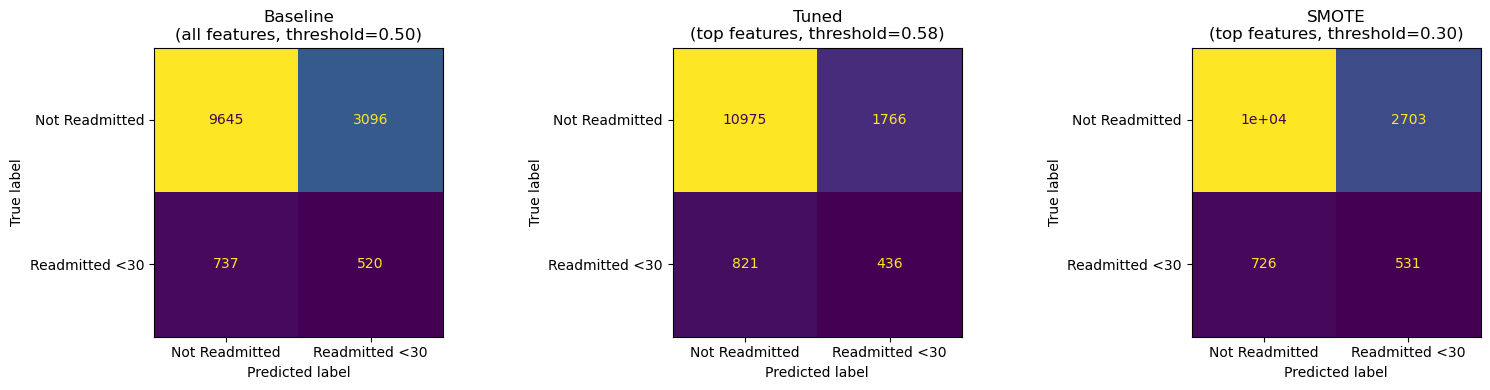

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, base_pred),
    display_labels=['Not Readmitted', 'Readmitted <30']
).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Baseline\n(all features, threshold=0.50)')

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_best),
    display_labels=['Not Readmitted', 'Readmitted <30']
).plot(ax=axes[1], colorbar=False)
axes[1].set_title(f'Tuned\n(top features, threshold={best_thresh:.2f})')

ConfusionMatrixDisplay(
    confusion_matrix(y_test, smote_pred_best),
    display_labels=['Not Readmitted', 'Readmitted <30']
).plot(ax=axes[2], colorbar=False)
axes[2].set_title(f'SMOTE\n(top features, threshold={smote_best_thresh:.2f})')

plt.tight_layout()
plt.savefig('../Results/XGB_Results/confusion_matrix_xgb.png', dpi=150)
plt.show()

Each matrix shows true/false positives and negatives. The key cells are bottom-left (false negatives — missed readmissions) and top-right (false positives — false alarms). SMOTE catches the most true readmissions but also generates the most false alarms. Tuned has fewer false positives but misses more actual cases. All three correctly classify the vast majority of non-readmitted patients (top-left), largely because that class dominates the dataset.

## ROC & Precision-Recall Curves

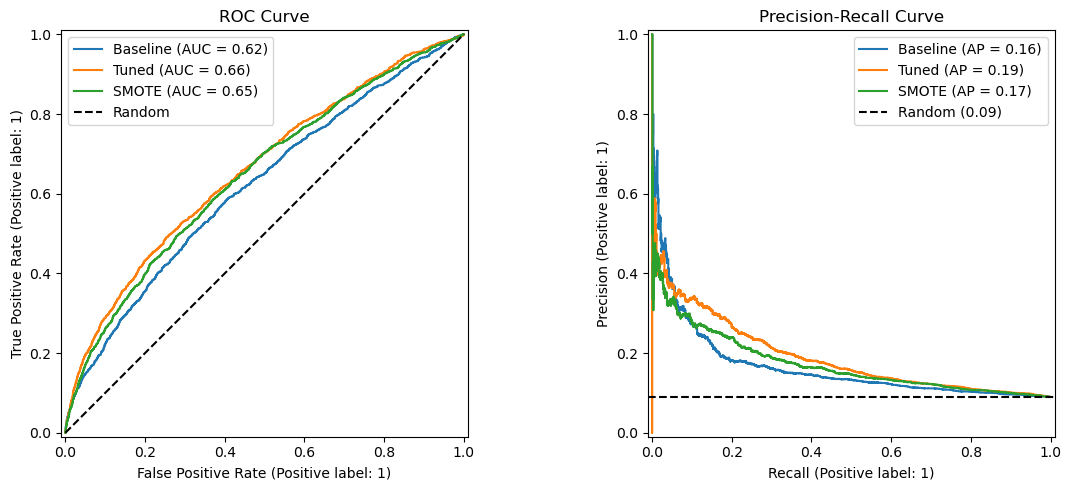

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(y_test, base_pred_prob,  ax=axes[0], name='Baseline')
RocCurveDisplay.from_predictions(y_test, y_pred_prob,     ax=axes[0], name='Tuned')
RocCurveDisplay.from_predictions(y_test, smote_pred_prob, ax=axes[0], name='SMOTE')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].set_title('ROC Curve')
axes[0].legend()

PrecisionRecallDisplay.from_predictions(y_test, base_pred_prob,  ax=axes[1], name='Baseline')
PrecisionRecallDisplay.from_predictions(y_test, y_pred_prob,     ax=axes[1], name='Tuned')
PrecisionRecallDisplay.from_predictions(y_test, smote_pred_prob, ax=axes[1], name='SMOTE')
axes[1].axhline(y_test.mean(), color='k', linestyle='--', label=f'Random ({y_test.mean():.2f})')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.savefig('../Results/XGB_Results/roc_pr_xgb.png', dpi=150)
plt.show()

The **ROC curves** show all three models clustered together and only modestly above the random diagonal, confirming limited discriminative power overall. The **Precision-Recall curve** is more informative for imbalanced data — the curves sit close to the random baseline (dashed at 0.09), showing how hard it is to identify the rare readmission class at high precision. Tuned edges above the others in both plots.

## Feature Importance

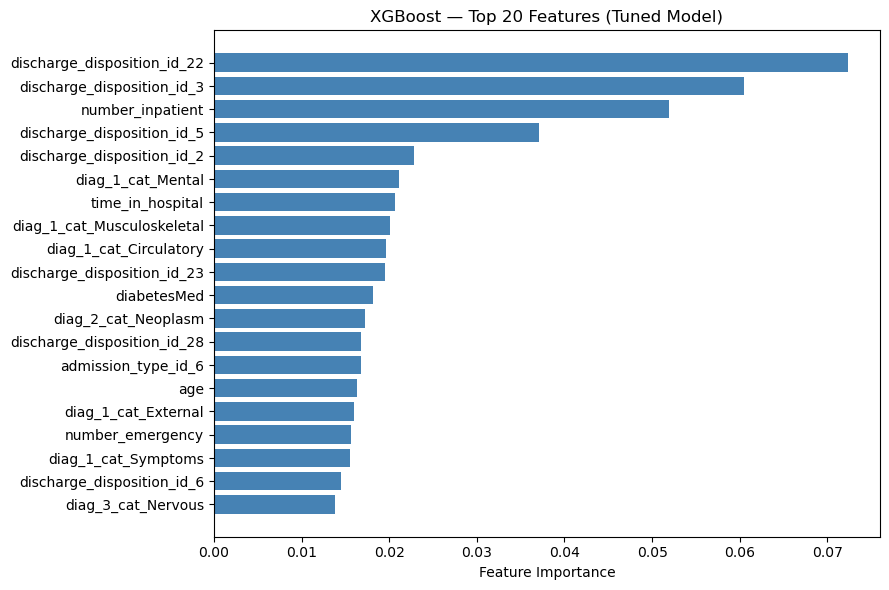

In [23]:
imp_df = (
    pd.DataFrame({'feature': X_train_top.columns, 'importance': model.feature_importances_})
    .sort_values('importance', ascending=False)
    .head(20)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1], color='steelblue')
ax.set_xlabel('Feature Importance')
ax.set_title('XGBoost — Top 20 Features (Tuned Model)')
plt.tight_layout()
plt.savefig('../Results/XGB_Results/feature_importance_xgb.png', dpi=150)
plt.show()

## Model Summary

In [24]:
metrics_rows = []
for name, probs, preds in [
    ('Baseline', base_pred_prob,  base_pred),
    ('Tuned',    y_pred_prob,     y_pred_best),
    ('SMOTE',    smote_pred_prob, smote_pred_best),
]:
    metrics_rows.append({
        'Model':                name,
        'ROC-AUC':              round(roc_auc_score(y_test, probs), 4),
        'Precision (minority)': round(precision_score(y_test, preds, pos_label=1, zero_division=0), 3),
        'Recall (minority)':    round(recall_score(y_test, preds), 3),
        'F1 (minority)':        round(f1_score(y_test, preds, pos_label=1, zero_division=0), 3),
        'Macro F1':             round(f1_score(y_test, preds, average='macro', zero_division=0), 3),
    })

pd.DataFrame(metrics_rows).set_index('Model')

,ROC-AUC,Precision (minority),Recall (minority),F1 (minority),Macro F1
Model,,,,,
Baseline,0.6186,0.144,0.414,0.213,0.524
Tuned,0.6601,0.198,0.347,0.252,0.573
SMOTE,0.6472,0.164,0.422,0.236,0.545


The **Tuned model** is the best XGBoost variant with the highest ROC-AUC (0.6601) and Macro F1 (0.573). All three models have low minority F1 scores (0.21–0.25), reflecting the difficulty of identifying rare readmissions. The overall modest performance suggests XGBoost may not be the strongest model in this project — compare against Logistic Regression and SVM to determine the best approach.